In [15]:
from brainhack.pulse import Tukey
from brainhack.sequence import Sequence, Modulation
from brainhack.system import System
from brainhack.simulator import Simulator

import matplotlib.pyplot as plt
import numpy as np

In [28]:
pulse = Tukey(
    duration = 1e-3,           # in s
    shape = .3,
    flipAngle = 299,            # in degree
    offset = 7000               # in Hz
)

sequence_noDummy = Sequence(
    modulation = Modulation.BP,
    pulse = pulse,
    N_pulsePerOffset = 1,
    N_pulse = 6,
    N_burst = 10,
    N_adc = 96,
    N_dummyADC = 0,
    dt_interPulse = 1.5e-3,     # in s
    TR_burst = 100e-3,             # in s
    dt_lastBurst = 9e-3,       # in s
    es = 6e-3,                 # in s
    tr = 20,                     # in s
    readout_flipAngle = 6       # in degree
)

sequence_withDummy = Sequence(
    modulation = Modulation.BP,
    pulse = pulse,
    N_pulsePerOffset = 1,
    N_pulse = 6,
    N_burst = 10,
    N_adc = 96,
    N_dummyADC = 50,
    dt_interPulse = 1.5e-3,     # in s
    TR_burst = 100e-3,             # in s
    dt_lastBurst = 9e-3,       # in s
    es = 6e-3,                 # in s
    tr = 20,                     # in s
    readout_flipAngle = 6       # in degree
)

system = System(
    pulse = pulse,
    poolFree_M0 = 1,
    poolBound_M0 = 0.1,
    poolFree_T1 = 1,                    # in s
    poolBound_T1 = 1,                    # in s 
    poolBound_T1D = 0.01,                 # in s
    poolFree_T2 = 0.1,                  # in s
    poolBound_T2 = 1e-5,                 # in s
    poolFreeBound_exchangeRate = 20                      # in s^-1
    )

simulator_noDummy = Simulator(
    system = system,
    sequence = sequence_noDummy,
    export_readMatrix = True,
)

simulator_withDummy = Simulator(
    system = system,
    sequence = sequence_withDummy,
    export_readMatrix = True,
)

# print(system.poolBound_M0)
# print(system.poolBound_M0 / system.poolBound_T1)

# system.RFabsorption_Matrix(pulse)

out = simulator_withDummy.SteadyState()


MT0 = out['MT0']
MTs = out['MTs']
MTds = [out['MTd_CM'], out['MTd_ALT']]

read = None
if 'readout' in out:
    read = out['readout']


In [29]:
out

{'MT0': array([0.80625098, 0.08369514, 0.        , 1.        ]),
 'MTs': array([0.69083882, 0.0716595 , 0.        , 1.        ]),
 'MTd_CM': array([0.57710867, 0.05980197, 0.        , 1.        ]),
 'MTd_ALT': array([0.58437616, 0.06055923, 0.        , 1.        ]),
 'readout': array([[9.77459365e-01, 1.11744793e-01, 0.00000000e+00, 5.98203595e-03],
        [1.11132643e-02, 8.82273171e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

In [30]:
print(MT0.shape)
print(MTs.shape)
print(MTds[0].shape)

if 'readout' in out:
    print(read.shape)

print(MT0[0])
print(MTs[0])
print(MTds[0][0])

(4,)
(4,)
(4,)
(4, 4)
0.8062509769138312
0.6908388194351167
0.5771086650808726


In [31]:
(4, 4)
print(0.8062509769138312 - 0.8062509769138312)
print(0.6908388239773408 - 0.6908388194351167)
print(0.5771086868643962 - 0.5771086650808726)

0.0
4.542224041337306e-09
2.1783523651563996e-08


In [32]:
print(MT0)
print(MTs)
for MTd in MTds:
    print(MTd)
if 'readout' in out:
    print(read)

[0.80625098 0.08369514 0.         1.        ]
[0.69083882 0.0716595  0.         1.        ]
[0.57710867 0.05980197 0.         1.        ]
[0.58437616 0.06055923 0.         1.        ]
[[9.77459365e-01 1.11744793e-01 0.00000000e+00 5.98203595e-03]
 [1.11132643e-02 8.82273171e-01 0.00000000e+00 5.98203595e-04]
 [0.00000000e+00 0.00000000e+00 5.48811636e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [33]:
ihMTR = 2*(MTs[0] - MTds[0][0]) / MT0[0] * 100
print(ihMTR)

28.212097128757758


In [34]:
flipAngle_nominal = pulse.flipAngle
print(f"Nominal flip angle: {flipAngle_nominal} degrees")

Nominal flip angle: 299 degrees


In [36]:
flipAngle_nominal = pulse.flipAngle
B1rel_range = np.linspace(.1, 1.5, 36)
ihMTR_values = []

for B1rel in B1rel_range:
    pulse.flipAngle = flipAngle_nominal * B1rel
    # pulse.compute()
    # system.RFabsorption_Matrix(pulse)
    # print(system.poolBound_Rrf_singleSat_Positive)
    out = simulator_withDummy.SteadyState()
    ihMTR_temp = 2*(out['MTs'][0] - out['MTd_CM'][0]) / out['MT0'][0] * 100
    ihMTR_values.append(ihMTR_temp)

# reset flip angle to nominal
pulse.flipAngle = flipAngle_nominal

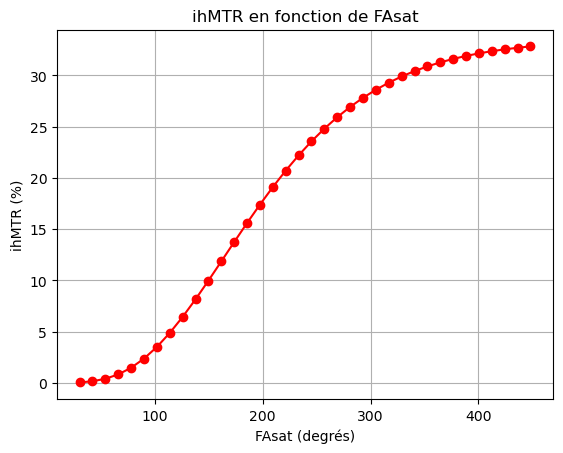

In [37]:
# Tracer ihMTR en fonction de B1rel
plt.plot(B1rel_range*flipAngle_nominal, ihMTR_values, marker='o', linestyle='-', color='r')
plt.xlabel('FAsat (degrés)')
plt.ylabel('ihMTR (%)')
plt.title('ihMTR en fonction de FAsat')
plt.grid(True)
plt.show()

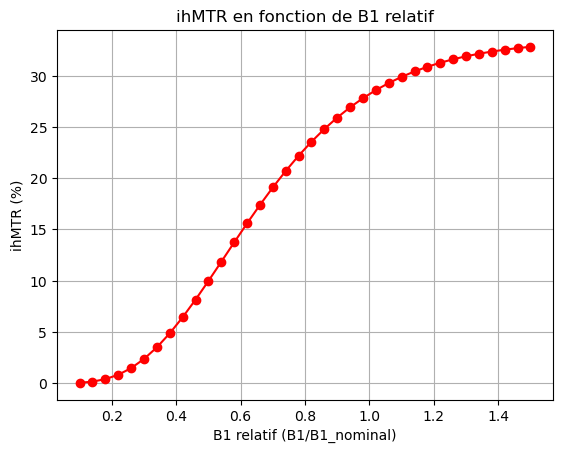

In [38]:
# Tracer ihMTR en fonction de B1rel
plt.plot(B1rel_range, ihMTR_values, marker='o', linestyle='-', color='r')
plt.xlabel('B1 relatif (B1/B1_nominal)')
plt.ylabel('ihMTR (%)')
plt.title('ihMTR en fonction de B1 relatif')
plt.grid(True)
plt.show()


In [39]:
(B1rel_range*flipAngle_nominal)[14]

np.float64(197.34)

In [40]:
print(ihMTR_values[0] - 0.04231110571522111)
print(ihMTR_values[14] - 17.389000246394353)
print(ihMTR_values[-1] - 32.819605396523635)

3.5275209399332486e-08
6.218568906035671e-06
1.1655137370780722e-06


In [44]:
MT0_noDummy, MTs_noDummy, *MTds_noDummy, read_noDummy = simulator_noDummy.SteadyState().values()
MT0_withDummy, MTs_withDummy, *MTds_withDummy, read_withDummy = simulator_withDummy.SteadyState().values()


In [47]:
inv_read_withDummy = np.linalg.inv(read_withDummy)
print('MT0')
print(np.linalg.matrix_power(inv_read_withDummy, 3) @ MT0_withDummy)
print(MT0_noDummy)
print(np.linalg.matrix_power(read_noDummy, 3) @ MT0_noDummy)
print(MT0_withDummy)

print('MTs')
print(np.linalg.matrix_power(inv_read_withDummy, 3) @ MTs_withDummy)
print(MTs_noDummy)
print(np.linalg.matrix_power(read_noDummy, 3) @ MTs_noDummy)
print(MTs_withDummy)

print('MTd CM')
print(np.linalg.matrix_power(inv_read_withDummy, 3) @ MTds_withDummy[0])
print(MTds_noDummy[0])
print(np.linalg.matrix_power(read_noDummy, 3) @ MTds_noDummy[0])
print(MTds_withDummy[0])

print('MTd ALT')
print(np.linalg.matrix_power(inv_read_withDummy, 3) @ MTds_withDummy[1])
print(MTds_noDummy[1])
print(np.linalg.matrix_power(read_noDummy, 3) @ MTds_noDummy[1])
print(MTds_withDummy[1])

MT0
[0.81495737 0.08459904 0.         1.        ]
[1.  0.1 0.  1. ]
[0.98418274 0.09966594 0.         1.        ]
[0.80625098 0.08369514 0.         1.        ]
MTs
[0.69569487 0.07214855 0.         1.        ]
[8.26734771e-01 5.38210264e-02 1.05332255e-06 1.00000000e+00]
[8.08357875e-01 6.27929902e-02 1.74113047e-07 1.00000000e+00]
[0.69083882 0.0716595  0.         1.        ]
MTd CM
[0.57816925 0.05988349 0.         1.        ]
[0.65339146 0.01080808 0.         1.        ]
[0.63337877 0.02810289 0.         1.        ]
[0.57710867 0.05980197 0.         1.        ]
MTd ALT
[0.5856795  0.06066657 0.         1.        ]
[ 6.64909008e-01  1.31346307e-02 -1.31947285e-07  1.00000000e+00]
[ 6.44850763e-01  3.00410796e-02 -2.18107396e-08  1.00000000e+00]
[0.58437616 0.06055923 0.         1.        ]


In [48]:
allMats = [np.linalg.matrix_power(read_noDummy, i) for i in range(sequence_noDummy.N_adc)]
allMTds = [None, None]
allMTRds = [None, None]
allihMTs = [None, None]
allihMTRs = [None, None]

allMT0 = np.array([mat @ MT0_noDummy for mat in allMats])

allMTs = np.array([mat @ MTs_noDummy for mat in allMats])
allMTRs = np.nan_to_num(100 * (1 - allMTs / allMT0), 0)

allMTds[0] = np.array([mat @ MTds_noDummy[0] for mat in allMats])
allMTRds[0] = np.nan_to_num(100 * (1 - allMTds[0] / allMT0), 0)

allMTds[1] = np.array([mat @ MTds_noDummy[1] for mat in allMats])
allMTRds[1] = np.nan_to_num(100 * (1 - allMTds[1] / allMT0), 0)

allihMTs[0] = 2 * (allMTs - allMTds[0])
allihMTRs[0] = np.nan_to_num(100 * allihMTs[0] / allMT0, 0)

allihMTs[1] = 2 * (allMTs - allMTds[1])
allihMTRs[1] = np.nan_to_num(100 * allihMTs[1] / allMT0, 0)

/tmp/ipykernel_21993/3673852593.py:10: RuntimeWarning: divide by zero encountered in divide
  allMTRs = np.nan_to_num(100 * (1 - allMTs / allMT0), 0)
/tmp/ipykernel_21993/3673852593.py:13: RuntimeWarning: invalid value encountered in divide
  allMTRds[0] = np.nan_to_num(100 * (1 - allMTds[0] / allMT0), 0)
/tmp/ipykernel_21993/3673852593.py:16: RuntimeWarning: divide by zero encountered in divide
  allMTRds[1] = np.nan_to_num(100 * (1 - allMTds[1] / allMT0), 0)
/tmp/ipykernel_21993/3673852593.py:19: RuntimeWarning: divide by zero encountered in divide
  allihMTRs[0] = np.nan_to_num(100 * allihMTs[0] / allMT0, 0)
/tmp/ipykernel_21993/3673852593.py:22: RuntimeWarning: divide by zero encountered in divide
  allihMTRs[1] = np.nan_to_num(100 * allihMTs[1] / allMT0, 0)


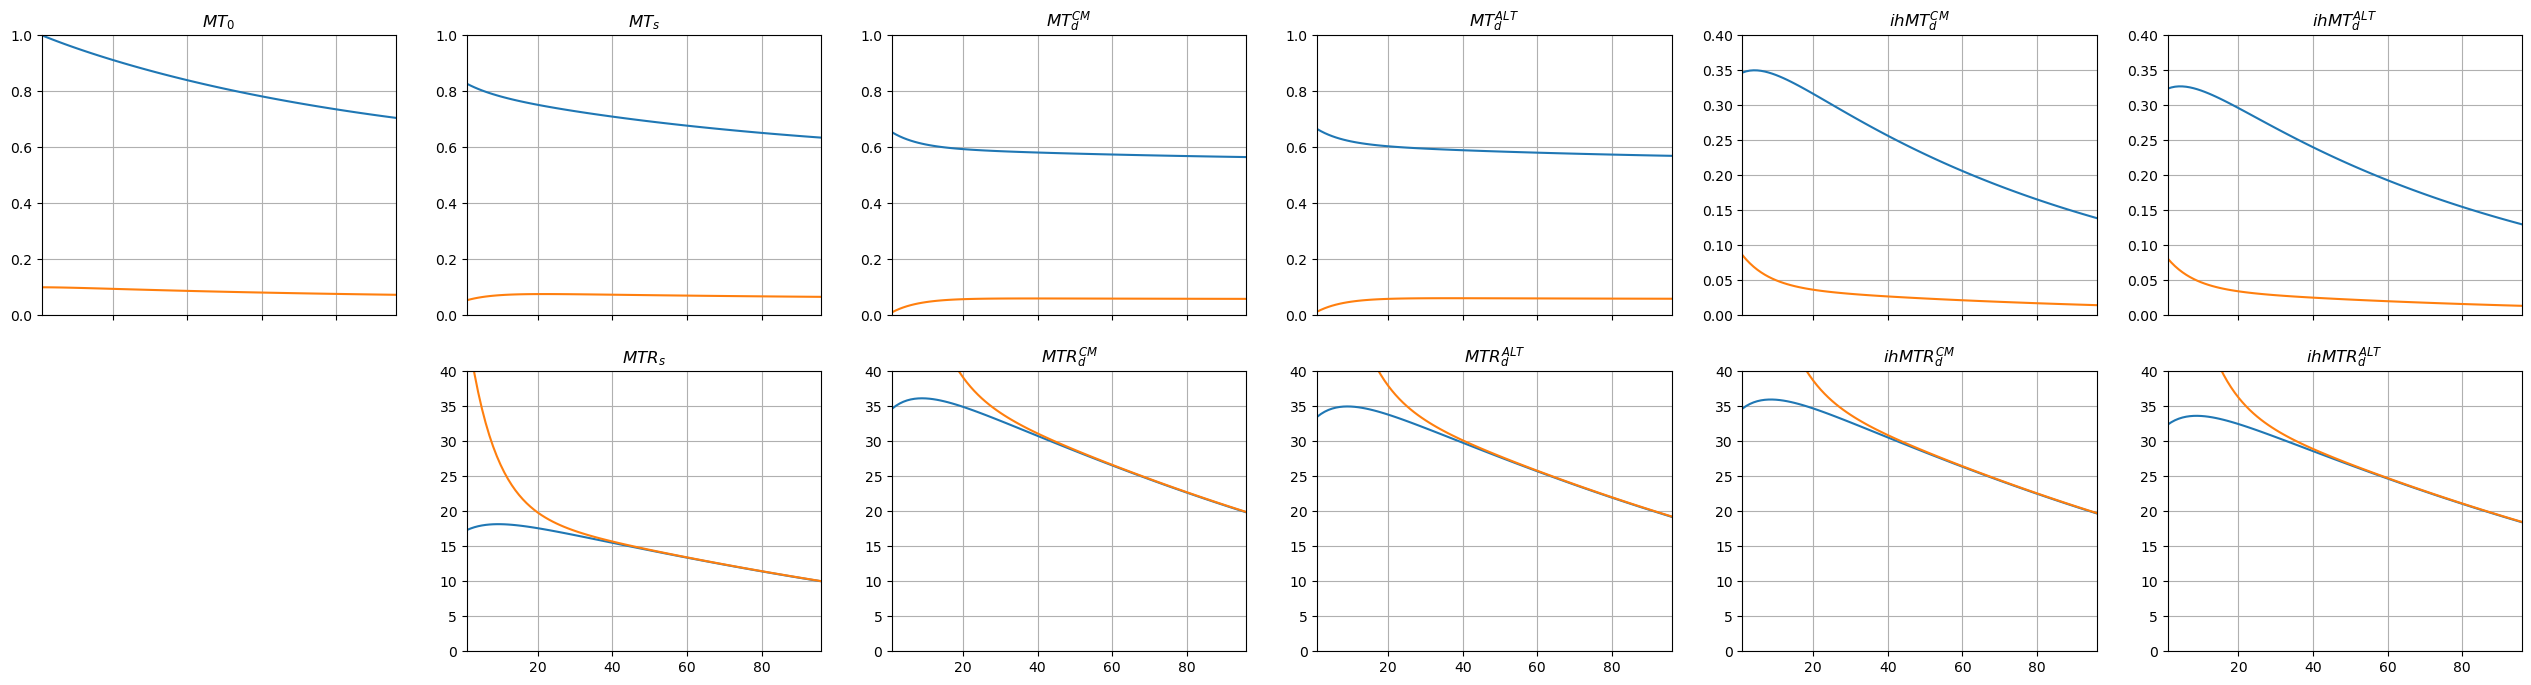

In [56]:
x = range(1, sequence_noDummy.N_adc + 1)

fig, axes = plt.subplots(2, 6, sharex=True, figsize=(32, 8))
axes = axes.flatten()

axes[0].set_title("$MT_0$")
axes[0].grid()
axes[0].set_ylim(0, 1)
axes[0].plot(x, allMT0[:,0:2])
axes[0].set_xlim(1, sequence_noDummy.N_adc)
axes[0 + 6].remove()

axes[1].set_title("$MT_s$")
axes[1].grid()
axes[1].set_ylim(0, 1)
axes[1].plot(x, allMTs[:,0:2])
axes[1 + 6].set_title("$MTR_s$")
axes[1 + 6].grid()
axes[1 + 6].set_ylim(0, 40)
axes[1 + 6].plot(x, allMTRs[:,0:2])

axes[2].set_title("$MT_d^{CM}$")
axes[2].grid()
axes[2].set_ylim(0, 1)
axes[2].plot(x, allMTds[0][:,0:2])
axes[2 + 6].set_title("$MTR_d^{CM}$")
axes[2 + 6].grid()
axes[2 + 6].set_ylim(0, 40)
axes[2 + 6].plot(x, allMTRds[0][:,0:2])

axes[3].set_title("$MT_d^{ALT}$")
axes[3].grid()
axes[3].set_ylim(0, 1)
axes[3].plot(x, allMTds[1][:,0:2])
axes[3 + 6].set_title("$MTR_d^{ALT}$")
axes[3 + 6].grid()
axes[3 + 6].set_ylim(0, 40)
axes[3 + 6].plot(x, allMTRds[1][:,0:2])

axes[4].set_title("$ihMT_d^{CM}$")
axes[4].grid()
axes[4].set_ylim(0, .40)
axes[4].plot(x, allihMTs[0][:,0:2])
axes[4 + 6].set_title("$ihMTR_d^{CM}$")
axes[4 + 6].grid()
axes[4 + 6].set_ylim(0, 40)
axes[4 + 6].plot(x, allihMTRs[0][:,0:2])

axes[5].set_title("$ihMT_d^{ALT}$")
axes[5].grid()
axes[5].set_ylim(0, .40)
axes[5].plot(x, allihMTs[1][:,0:2])
axes[5 + 6].set_title("$ihMTR_d^{ALT}$")
axes[5 + 6].grid()
axes[5 + 6].set_ylim(0, 40)
axes[5 + 6].plot(x, allihMTRs[1][:,0:2])

plt.show()

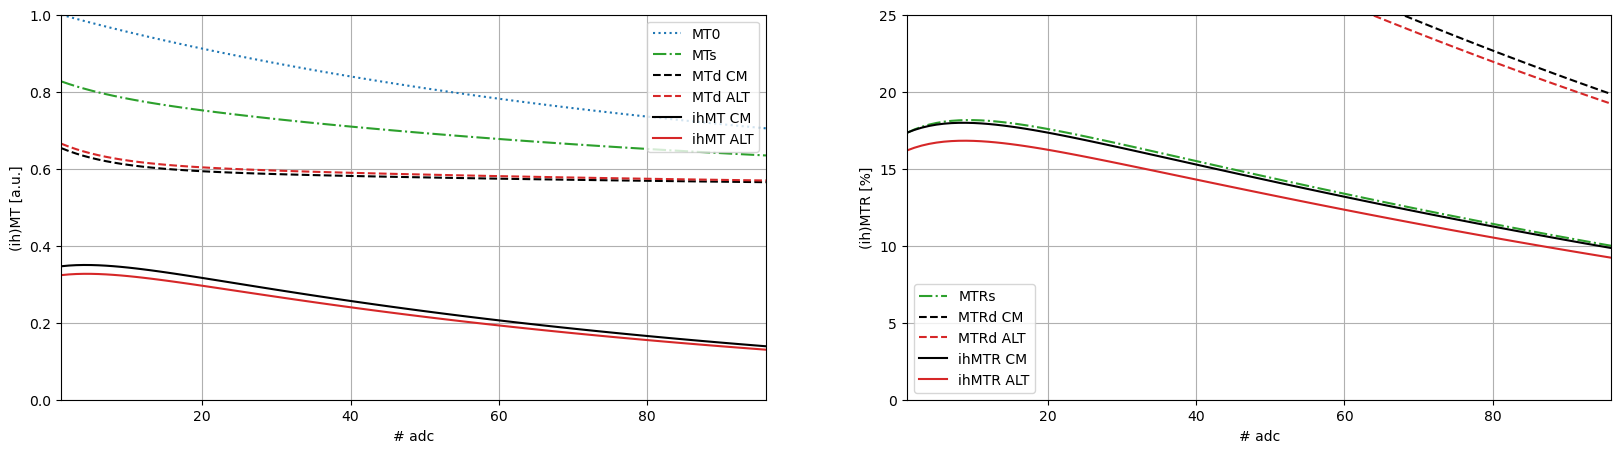

In [50]:
x = range(1, sequence_noDummy.N_adc + 1)

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20, 5))
axes = axes.flatten()

axes[0].plot(x, allMT0.T[0], color='C0', linestyle='dotted', label='MT0')
axes[0].plot(x, allMTs.T[0], color='C2', linestyle='-.', label='MTs')
axes[0].plot(x, allMTds[0].T[0], color='k', linestyle='--', label='MTd CM')
axes[0].plot(x, allMTds[1].T[0], color='C3', linestyle='--', label='MTd ALT')
axes[0].plot(x, allihMTs[0].T[0], color='k', linestyle='-', label='ihMT CM')
axes[0].plot(x, allihMTs[1].T[0], color='C3', linestyle='-', label='ihMT ALT')

axes[1].plot(x, allMTRs.T[0], color='C2', linestyle='-.', label='MTRs')
axes[1].plot(x, allMTRds[0].T[0], color='k', linestyle='--', label='MTRd CM')
axes[1].plot(x, allMTRds[1].T[0], color='C3', linestyle='--', label='MTRd ALT')
axes[1].plot(x, .5 * allihMTRs[0].T[0], color='k', linestyle='-', label='ihMTR CM')
axes[1].plot(x, .5 * allihMTRs[1].T[0], color='C3', linestyle='-', label='ihMTR ALT')

axes[0].legend()
axes[0].grid()
axes[0].set_xlabel('# adc')
axes[0].set_xlim(1, sequence_noDummy.N_adc)
axes[0].set_ylabel('(ih)MT [a.u.]')
axes[0].set_ylim(0, 1)

axes[1].legend()
axes[1].grid()
axes[1].set_xlabel('# adc')
axes[1].set_xlim(1, sequence_noDummy.N_adc)
axes[1].set_ylabel('(ih)MTR [%]')
axes[1].set_ylim(0, 25)

plt.show()

